## **1. Project Title and Aim**

LINK FOR DATASET



**Title:**  
**A Hybrid Time-Series Framework for Early Detection and Slow Drift Detection of Household Energy Inefficiency Using Smart Meter, Weather, and Carbon Intensity Data**

**Aim:**  
To develop a **multi-household time-series framework** that integrates **forecasting** and **residual-based monitoring** to detect **early inefficiency events** and **slow drift** in electricity consumption while assessing **environmental impact**.

**Objectives:**  
- To preprocess and integrate **smart meter, weather, and carbon intensity data**  
- To analyse **temporal consumption patterns** across households  
- To develop forecasting models using **TCN** and **XGBoost**  
- To detect inefficiency-related drift using **STL, CUSUM, and EWMA**  
- To enable **early anomaly detection** and **slow drift detection**  
- To evaluate **drift severity** and **model performance**  
- To analyse the **carbon impact** of excess energy consumption  
- To apply **Explainable AI (SHAP and permutation importance)**  
- To simulate **pseudo real-time monitoring** and **alert generation**  

**Observation:**  
Electricity consumption evolves over time with both **sudden changes** and **gradual behavioural shifts** influenced by **internal and external factors**.

**Interpretation:**  
A hybrid approach combining **forecasting**, **statistical monitoring**, and **explainable AI** provides a **scalable**, **interpretable**, and **real-world applicable solution** for detecting and managing household energy inefficiency.

## **2. Imports and Setup**

In [ ]:
# ============================================================
# CELL:Environment Setup and Library Imports
# Purpose:
# This cell installs and imports all required libraries for
# data preprocessing, forecasting, drift detection, explainability,
# and visualization used in the project.
# ============================================================

# Install required packages
!pip install keras-tcn -q
!pip install xgboost -q
!pip install statsmodels -q
!pip install shap -q
!pip install streamlit -q

# -------------------------
# Standard Python libraries
# -------------------------
import os
import re
import glob
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# Data handling libraries
# -------------------------
import numpy as np
import pandas as pd

# -------------------------
# Visualization libraries
# -------------------------
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_theme(style="whitegrid", context="talk")

# -------------------------
# Scikit-learn utilities
# -------------------------
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# -------------------------
# Time-series decomposition
# -------------------------
from statsmodels.tsa.seasonal import STL

# -------------------------
# Deep learning libraries
# -------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tcn import TCN

# -------------------------
# Machine learning model
# -------------------------
from xgboost import XGBRegressor

# -------------------------
# Explainable AI library
# -------------------------
import shap

# -------------------------
# Display settings
# -------------------------
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# -------------------------
# Plot settings
# -------------------------
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# -------------------------
# Reproducibility
# -------------------------
SEED = 42
np.random.seed(SEED)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## **3. Mount Google Drive and Define Paths**

In [ ]:
# ============================================================
# CELL:Data Access and File Paths
# Purpose:
# Mount Google Drive and define file paths for all datasets
# used in the project.
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Energy data (multiple household files)
energy_glob = "/content/drive/MyDrive/Energy/LCL-June2015v2_*.csv"

# Weather data (temperature variables)
tg_path = "/content/drive/MyDrive/Weather/TG_STAID001860.txt"  # Mean temp
tx_path = "/content/drive/MyDrive/Weather/TX_STAID001860.txt"  # Max temp
tn_path = "/content/drive/MyDrive/Weather/TN_STAID001860.txt"  # Min temp

# Carbon intensity data
carbon_path = "/content/drive/MyDrive/Carbon Intensity Dataset.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **4. Load and Merge Electricity Files**

In [ ]:
# ============================================================
# CELL:Load and Sort Energy Data Files
# Purpose:
# Extract and sort multiple household energy files in correct order
# ============================================================

# Function to extract file number for proper sorting
def extract_number(filename: str) -> int:
    match = re.search(r'_(\d+)\.csv$', filename)
    return int(match.group(1)) if match else -1

# Get all energy files
energy_files = glob.glob(energy_glob)

# Sort files numerically (important for consistency)
energy_files_sorted = sorted(energy_files, key=extract_number)

# Display results
print("Total energy files found:", len(energy_files_sorted))
print("Example files:", energy_files_sorted[:3])

Total energy files found: 168
Example files: ['/content/drive/MyDrive/Energy/LCL-June2015v2_0.csv', '/content/drive/MyDrive/Energy/LCL-June2015v2_1.csv', '/content/drive/MyDrive/Energy/LCL-June2015v2_2.csv']


**Observation**:
A total of 168 energy data files were identified and successfully sorted in numerical order.

### **4.1 Choose Number of Files**

In [ ]:
# ============================================================
# CELL:Load and Combine Energy Data
# Purpose:
# Select a subset of files and combine them into a single dataset
# for multi-household analysis.
# ============================================================

# Number of files to use (scalability control)
N_FILES = 50
files_to_use = energy_files_sorted[:N_FILES]

print("Number of selected files:", len(files_to_use))


Number of selected files: 50


In [ ]:
energy_parts = []

# Load each file and append to list
for fp in files_to_use:
    temp_df = pd.read_csv(fp, low_memory=False)
    temp_df["source_file"] = os.path.basename(fp)  # track file origin
    energy_parts.append(temp_df)

# Combine all files into one DataFrame
energy_raw = pd.concat(energy_parts, ignore_index=True)

# Standardize column names
energy_raw.columns = energy_raw.columns.str.strip().str.lower()

print("Combined shape:", energy_raw.shape)

# Preview data
energy_raw.head()

Combined shape: (50000000, 5)


,lclid,stdortou,datetime,kwh/hh (per half hour),source_file
0,MAC000002,Std,2012-10-12 00:30:00.0000000,0,LCL-June2015v2_0.csv
1,MAC000002,Std,2012-10-12 01:00:00.0000000,0,LCL-June2015v2_0.csv
2,MAC000002,Std,2012-10-12 01:30:00.0000000,0,LCL-June2015v2_0.csv
3,MAC000002,Std,2012-10-12 02:00:00.0000000,0,LCL-June2015v2_0.csv
4,MAC000002,Std,2012-10-12 02:30:00.0000000,0,LCL-June2015v2_0.csv


**Observation**:50 energy files were successfully loaded and combined into a single dataset containing 50 million records.

## **5. Clean Electricity Data**

**Why this is important**:

Cleaning ensures that the dataset is consistent, free from invalid values, and properly formatted for time-series analysis and modelling.

In [ ]:
# ============================================================
# CELL: Data Cleaning and Preprocessing
# ============================================================

# Rename columns for consistency
energy_raw = energy_raw.rename(columns={
    "lclid": "LCLid",
    "stdortou": "stdorToU",
    "kwh/hh (per half hour)": "kwh_hh"
})

# Convert data types
energy_raw["datetime"] = pd.to_datetime(energy_raw["datetime"], errors="coerce")
energy_raw["kwh_hh"] = pd.to_numeric(energy_raw["kwh_hh"], errors="coerce")

# Remove invalid/missing records
energy_raw = energy_raw.dropna(subset=["LCLid", "datetime", "kwh_hh"])

# Create daily date column for aggregation
energy_raw["date"] = energy_raw["datetime"].dt.normalize()

# Check results
print("Cleaned shape:", energy_raw.shape)
print(energy_raw.isna().sum())

energy_raw.head()

Cleaned shape: (49998412, 6)
LCLid          0
stdorToU       0
datetime       0
kwh_hh         0
source_file    0
date           0
dtype: int64


,LCLid,stdorToU,datetime,kwh_hh,source_file,date
0,MAC000002,Std,2012-10-12 00:30:00,0.000,LCL-June2015v2_0.csv,2012-10-12
1,MAC000002,Std,2012-10-12 01:00:00,0.000,LCL-June2015v2_0.csv,2012-10-12
2,MAC000002,Std,2012-10-12 01:30:00,0.000,LCL-June2015v2_0.csv,2012-10-12
3,MAC000002,Std,2012-10-12 02:00:00,0.000,LCL-June2015v2_0.csv,2012-10-12
4,MAC000002,Std,2012-10-12 02:30:00,0.000,LCL-June2015v2_0.csv,2012-10-12


## **6. Aggregate to Daily Household Consumption**

**Why daily aggregation?**

Half-hourly data is noisy and very large. Aggregating to daily level reduces noise and provides a more stable signal for forecasting and drift detection.

In [ ]:
# ============================================================
# CELL: Daily Aggregation
# ============================================================

# Aggregate half-hourly data into daily household consumption
energy_daily = (
    energy_raw.groupby(["LCLid", "date"], as_index=False)["kwh_hh"]
    .sum()
    .rename(columns={"kwh_hh": "daily_kWh"})
)

# Log transform to stabilize variance
energy_daily["daily_kWh_log"] = np.log1p(energy_daily["daily_kWh"])

# Summary statistics
print("Daily shape:", energy_daily.shape)
print("Households:", energy_daily["LCLid"].nunique())
print("Date range:", energy_daily["date"].min(), "to", energy_daily["date"].max())

energy_daily.head()

Daily shape: (1045743, 4)
Households: 1587
Date range: 2011-11-23 00:00:00 to 2014-02-28 00:00:00


,LCLid,date,daily_kWh,daily_kWh_log
0,MAC000002,2012-10-12,7.098,2.092
1,MAC000002,2012-10-13,11.087,2.492
2,MAC000002,2012-10-14,13.223,2.655
3,MAC000002,2012-10-15,10.257,2.421
4,MAC000002,2012-10-16,9.769,2.377


**Observation**:

Half-hourly data was successfully aggregated into daily consumption, resulting in over 1 million records across 1587 households.

**Interpretation**:Daily aggregation provides a smoother and more reliable time-series representation, improving the effectiveness of forecasting models and drift detection methods.

## **7. Household Coverage Analysis**

**Data completeness overview**:

Before modelling, it is essential to understand how consistently each household is recorded over time, as gaps or irregular coverage can affect trend analysis and drift detection.

In [ ]:
# ============================================================
# CELL: Household Coverage Summary
# ============================================================

# Prepare sorted dataset for consistent time-series analysis
df_cov = energy_daily.copy()
df_cov = df_cov.sort_values(["LCLid", "date"]).reset_index(drop=True)

# Compute per-household coverage and consumption statistics
coverage = df_cov.groupby("LCLid").agg(
    start=("date", "min"),
    end=("date", "max"),
    n_days=("date", "count"),
    mean_kwh=("daily_kWh", "mean"),
    median_kwh=("daily_kWh", "median"),
    std_kwh=("daily_kWh", "std")
).reset_index()

# Compare actual records with expected span
coverage["span_days"] = (coverage["end"] - coverage["start"]).dt.days + 1
coverage["missing_days_est"] = coverage["span_days"] - coverage["n_days"]

# Rank households by data availability
coverage = coverage.sort_values("n_days", ascending=False)

coverage.head()

,LCLid,start,end,n_days,mean_kwh,median_kwh,std_kwh,span_days,missing_days_est
124,MAC000151,2011-11-23,2014-02-28,829,3.741,3.735,0.698,829,0
130,MAC000157,2011-11-23,2014-02-28,829,11.524,11.088,2.692,829,0
126,MAC000153,2011-11-23,2014-02-28,829,30.751,29.100,11.946,829,0
125,MAC000152,2011-11-23,2014-02-28,829,9.306,8.898,4.713,829,0
123,MAC000150,2011-11-23,2014-02-28,829,9.751,8.783,4.021,829,0


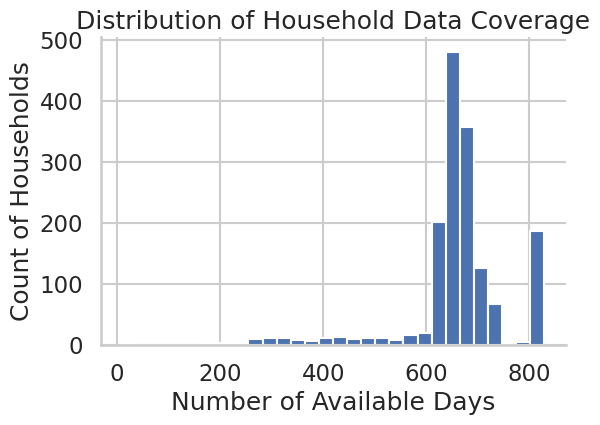

In [ ]:
# Plot distribution of number of available days per household
plt.figure(figsize=(6,4))

# Histogram to show how data coverage varies across households
plt.hist(coverage["n_days"], bins=30)

# Add title and axis labels for clarity
plt.title("Distribution of Household Data Coverage")
plt.xlabel("Number of Available Days")
plt.ylabel("Count of Households")

plt.show()

**Observation**:

Most households are concentrated around high coverage (≈600–800 days), with a smaller number having significantly lower data availability.

**Interpretation**:

This indicates that the majority of households have sufficiently long time-series records for modelling, while a minority may require filtering or special handling due to limited data.

## **8. Load Weather Data**

In [ ]:
# ============================================================
# CELL: Load and Prepare Weather Data
# ============================================================

# Function to load ECAD weather data and extract relevant columns
def load_ecad(path: str, value_col: str, q_col: str) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=20)  # skip metadata rows
    df.columns = ["SOUID", "DATE", value_col, q_col]
    df["date"] = pd.to_datetime(df["DATE"], format="%Y%m%d", errors="coerce")
    return df[["date", value_col]]

# Load temperature datasets
tg = load_ecad(tg_path, "TG", "Q_TG")
tx = load_ecad(tx_path, "TX", "Q_TX")
tn = load_ecad(tn_path, "TN", "Q_TN")

# Convert temperature values (stored as tenths of °C)
tg["temp_mean"] = tg["TG"] / 10
tx["temp_max"] = tx["TX"] / 10
tn["temp_min"] = tn["TN"] / 10

# Merge into a single weather dataset
weather = (
    tg[["date", "temp_mean"]]
    .merge(tx[["date", "temp_max"]], on="date", how="inner")
    .merge(tn[["date", "temp_min"]], on="date", how="inner")
)

print("Weather shape:", weather.shape)
weather.head()

Weather shape: (17166, 4)


,date,temp_mean,temp_max,temp_min
0,1979-01-02,-2.600,1.600,-7.500
1,1979-01-03,-2.800,1.300,-7.200
2,1979-01-04,-2.600,-0.300,-6.500
3,1979-01-05,-0.800,5.600,-1.400
4,1979-01-06,-0.500,8.300,-6.600


**Observation**:The weather dataset contains over 17,000 daily records with temperature features spanning a long historical period.

**Interpretation**:
This provides sufficient temporal coverage to align with energy data and incorporate weather-driven patterns into the analysis.

## **9. Load Carbon Intensity Data**

In [ ]:
# ============================================================
# CELL: Load and Aggregate Carbon Intensity Data
# ============================================================

# Load dataset and convert datetime
carbon_raw = pd.read_csv(carbon_path)
carbon_raw["DATETIME"] = pd.to_datetime(carbon_raw["DATETIME"], errors="coerce")

# Create daily date column
carbon_raw["date"] = carbon_raw["DATETIME"].dt.normalize()

# Aggregate to daily average carbon intensity
carbon_daily = (
    carbon_raw.groupby("date", as_index=False)["CARBON_INTENSITY"]
    .mean()
    .rename(columns={"CARBON_INTENSITY": "carbon_intensity"})
)

print("Carbon daily shape:", carbon_daily.shape)
carbon_daily.head()

Carbon daily shape: (6263, 2)


,date,carbon_intensity
0,2009-01-01,541.688
1,2009-01-02,571.938
2,2009-01-03,566.750
3,2009-01-04,565.938
4,2009-01-05,586.042


**Observation**:

The carbon dataset contains over 6,000 daily records with varying carbon intensity values over time.

**Interpretation**:

This provides sufficient temporal coverage to analyse how changes in electricity usage relate to environmental impact.

## **10. Merge Energy, Weather, and Carbon Data**

**Data integration step**:

Combining energy consumption with weather and carbon intensity data allows the model to capture both behavioural and external environmental influences on electricity usage.

In [ ]:
# ============================================================
# CELL: Merge Energy, Weather, and Carbon Data
# ============================================================

# Align date range across datasets
start_date = energy_daily["date"].min()
end_date = energy_daily["date"].max()

weather_f = weather[(weather["date"] >= start_date) & (weather["date"] <= end_date)].copy()
carbon_f = carbon_daily[(carbon_daily["date"] >= start_date) & (carbon_daily["date"] <= end_date)].copy()

# Merge datasets on date
merged = energy_daily.merge(weather_f, on="date", how="left")
merged2 = merged.merge(carbon_f, on="date", how="left")

# Check merged result
print("Merged shape:", merged2.shape)
print("Missing values:")
print(merged2[["temp_mean", "temp_max", "temp_min", "carbon_intensity"]].isna().sum())

merged2.head()

Merged shape: (1045743, 8)
Missing values:
temp_mean           0
temp_max            0
temp_min            0
carbon_intensity    0
dtype: int64


,LCLid,date,daily_kWh,daily_kWh_log,temp_mean,temp_max,temp_min,carbon_intensity
0,MAC000002,2012-10-12,7.098,2.092,12.300,13.500,9.700,527.625
1,MAC000002,2012-10-13,11.087,2.492,9.600,12.900,5.600,556.479
2,MAC000002,2012-10-14,13.223,2.655,7.400,14.200,1.900,547.667
3,MAC000002,2012-10-15,10.257,2.421,8.600,15.900,2.900,549.333
4,MAC000002,2012-10-16,9.769,2.377,12.100,17.500,8.300,540.667


**Observation**:

The merged dataset contains over 1 million records with all weather and carbon features fully populated and aligned with energy data.

**Interpretation**:

This confirms a high-quality integrated dataset, enabling reliable modelling of energy consumption with environmental and external influences included.

## **11. Exploratory Data Analysis**

### **11.1 Distribution of Log Consumption**

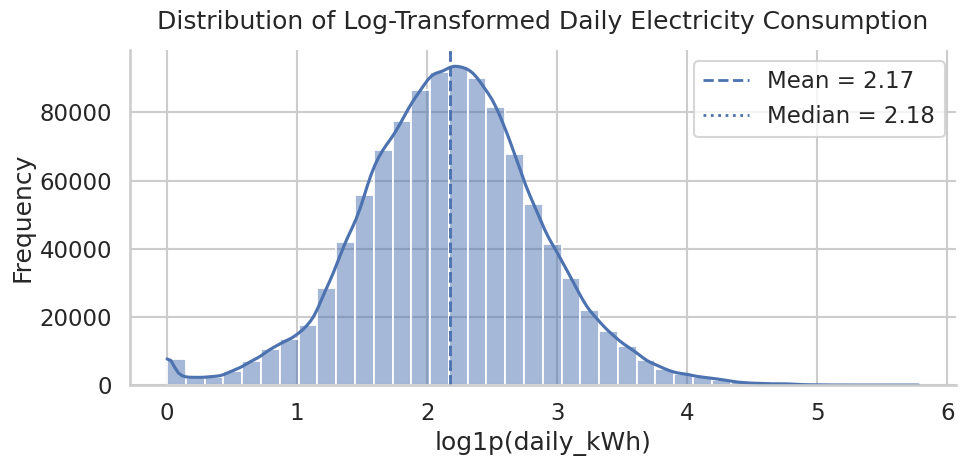

In [ ]:
# ============================================================
# CELL: Distribution of Log-Transformed Energy Consumption
# ============================================================

# Plot distribution of log-transformed daily consumption
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=merged2,
    x="daily_kWh_log",
    bins=40,
    kde=True,
    ax=ax
)

# Calculate central tendency
mean_val = merged2["daily_kWh_log"].mean()
median_val = merged2["daily_kWh_log"].median()

# Add reference lines for mean and median
ax.axvline(mean_val, linestyle="--", linewidth=2, label=f"Mean = {mean_val:.2f}")
ax.axvline(median_val, linestyle=":", linewidth=2, label=f"Median = {median_val:.2f}")

# Labels and formatting
ax.set_title("Distribution of Log-Transformed Daily Electricity Consumption", pad=15)
ax.set_xlabel("log1p(daily_kWh)")
ax.set_ylabel("Frequency")
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

**Observation**:

The log-transformed consumption follows a near-symmetric distribution, with mean and median values closely aligned.

**Interpretation**:

This indicates that the log transformation has effectively reduced skewness, making the data more suitable for modelling and statistical analysis.

## **11.2 Correlation Matrix**

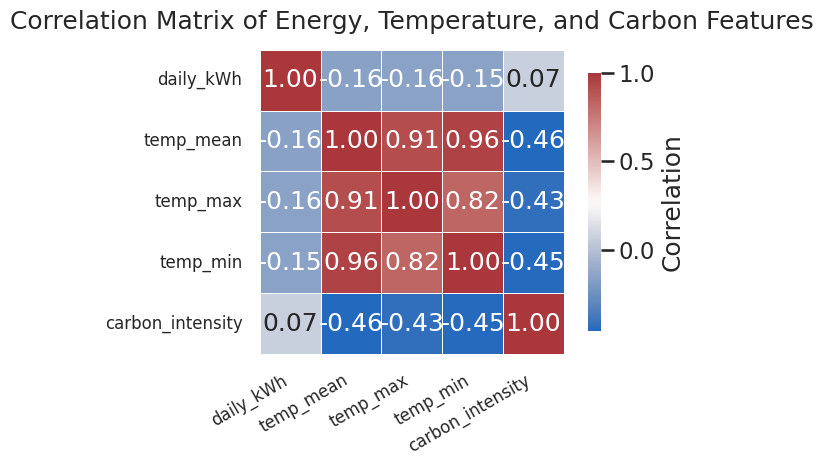

In [ ]:
# ============================================================
# CELL: Correlation Analysis
# ============================================================

# Select key features and compute correlation matrix
corr = merged2[["daily_kWh", "temp_mean", "temp_max", "temp_min", "carbon_intensity"]].corr()

# Visualize relationships between energy, temperature, and carbon variables
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap="vlag",
    fmt=".2f",
    linewidths=0.7,
    square=True,
    cbar_kws={"shrink": 0.85, "label": "Correlation"}
)

# Formatting
plt.title("Correlation Matrix of Energy, Temperature, and Carbon Features", pad=15)
plt.xticks(fontsize=12, rotation=30, ha="right")
plt.yticks(fontsize=12, rotation=0)

plt.tight_layout()
plt.show()

**Observation**:

Energy consumption shows a weak negative relationship with temperature, while temperature variables are highly correlated. Carbon intensity has a weak relationship with energy and a moderate negative correlation with temperature.

**Interpretation**:

This indicates higher energy use in colder conditions, while carbon intensity is influenced by factors beyond consumption, such as the energy generation mix.

### **11.3 Monthly Seasonality**

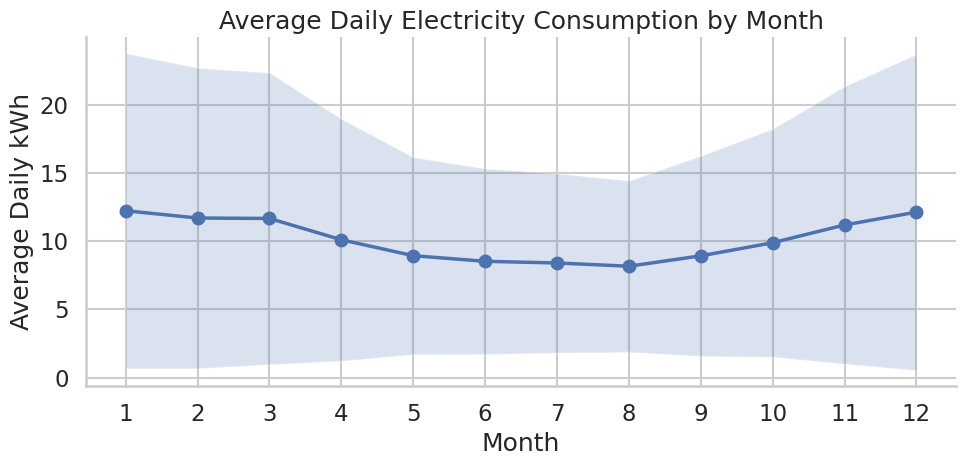

In [ ]:
# ============================================================
# CELL: Monthly Seasonality in Energy Consumption
# ============================================================

# Compute monthly mean and variability of daily consumption
monthly_stats = merged2.groupby(merged2["date"].dt.month)["daily_kWh"].agg(["mean", "std"]).reset_index()

# Plot average daily consumption by month
plt.figure(figsize=(10, 5))
plt.plot(monthly_stats["date"], monthly_stats["mean"], marker="o", linewidth=2.5)

# Add variability band using one standard deviation
plt.fill_between(
    monthly_stats["date"],
    monthly_stats["mean"] - monthly_stats["std"],
    monthly_stats["mean"] + monthly_stats["std"],
    alpha=0.2
)

plt.title("Average Daily Electricity Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily kWh")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

**Observation**:

Average daily electricity consumption is higher in winter months and lower during summer.

**Interpretation**:

This seasonal pattern suggests that household electricity use is influenced by weather-related demand, which is important for forecasting and drift interpretation.

### **11.4 Outliers**

Outlier rows: 61407
Outlier percentage: 5.87 %


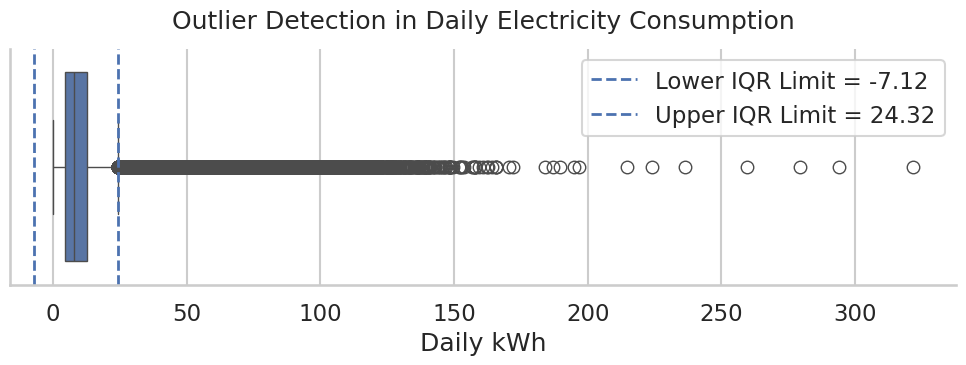

In [ ]:
# ============================================================
# CELL: Outlier Detection in Daily Electricity Consumption
# ============================================================

# Compute IQR-based thresholds
Q1 = merged2["daily_kWh"].quantile(0.25)
Q3 = merged2["daily_kWh"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Identify outlier records
outliers = merged2[(merged2["daily_kWh"] < lower) | (merged2["daily_kWh"] > upper)]

print("Outlier rows:", len(outliers))
print("Outlier percentage:", round(100 * len(outliers) / len(merged2), 2), "%")

# Visualize distribution and outlier limits
fig, ax = plt.subplots(figsize=(10, 4))

sns.boxplot(x=merged2["daily_kWh"], ax=ax)
ax.axvline(lower, linestyle="--", linewidth=2, label=f"Lower IQR Limit = {lower:.2f}")
ax.axvline(upper, linestyle="--", linewidth=2, label=f"Upper IQR Limit = {upper:.2f}")

ax.set_title("Outlier Detection in Daily Electricity Consumption", pad=15)
ax.set_xlabel("Daily kWh")
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

**Observation**:
Around 5.87% of records were identified as outliers, with most extreme values occurring on the higher consumption side.

**Interpretation**:
This suggests occasional unusually high electricity usage across households, which may reflect abnormal behaviour, peak demand events, or inefficiency-related consumption patterns.

### **11.5 Temperature vs Energy**

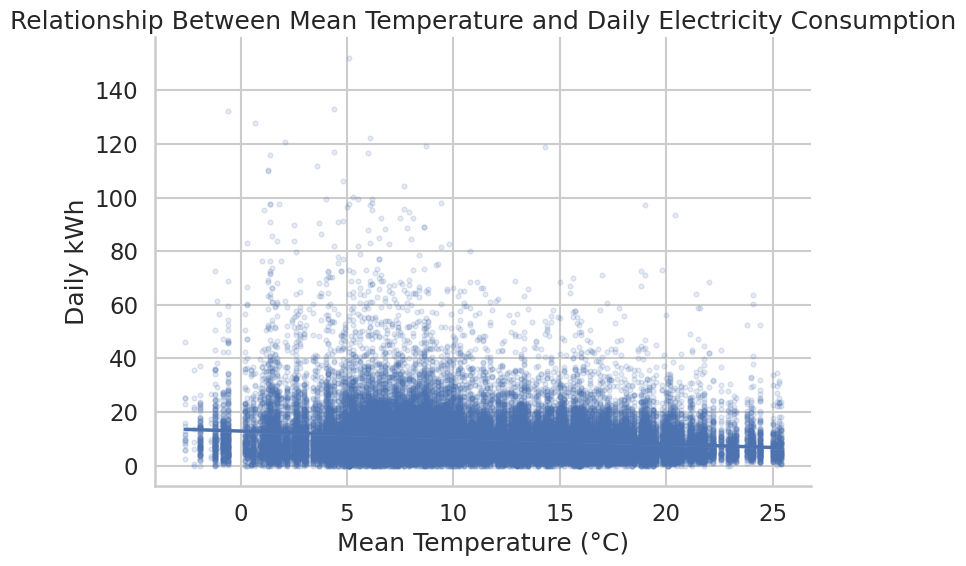

In [ ]:
# ============================================================
# CELL: Temperature vs Energy Consumption
# ============================================================

# Sample data for efficient visualization
sample_df = merged2.sample(min(50000, len(merged2)), random_state=42)

# Plot relationship between temperature and energy usage
plt.figure(figsize=(8, 6))
sns.regplot(
    data=sample_df,
    x="temp_mean",
    y="daily_kWh",
    scatter_kws={"alpha": 0.15, "s": 12},
    line_kws={"linewidth": 2.5}
)

plt.title("Relationship Between Mean Temperature and Daily Electricity Consumption")
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Daily kWh")

plt.tight_layout()
plt.show()

**Observation**:

There is a slight negative trend between temperature and daily electricity consumption, with higher usage observed at lower temperatures.

**Interpretation**:

This indicates that energy demand increases in colder conditions, likely due to heating needs, reinforcing the influence of weather on consumption patterns.

### **11.6 Seasonal Heatmap of Electricity Consumption by Year and Month**

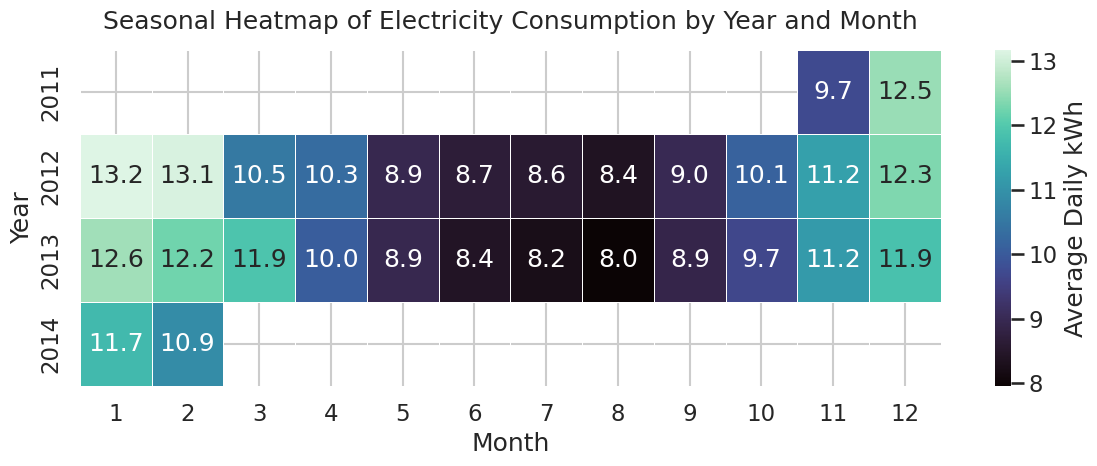

In [ ]:
# ============================================================
# CELL: Seasonal Heatmap of Electricity Consumption
# ============================================================

# Extract year and month for seasonal analysis
season_df = merged2.copy()
season_df["year"] = season_df["date"].dt.year
season_df["month"] = season_df["date"].dt.month

# Compute average daily consumption by year and month
season_pivot = season_df.groupby(["year", "month"])["daily_kWh"].mean().unstack()

# Visualize monthly consumption patterns across years
plt.figure(figsize=(12, 5))
sns.heatmap(
    season_pivot,
    cmap="mako",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Average Daily kWh"}
)

plt.title("Seasonal Heatmap of Electricity Consumption by Year and Month", pad=15)
plt.xlabel("Month")
plt.ylabel("Year")

plt.tight_layout()
plt.show()

**Observation**:

Electricity consumption is generally higher in winter months and lower in summer across most years.

**Interpretation**:

This consistent seasonal pattern reinforces the influence of weather and calendar effects on household energy demand.

### **11.7 Missingness Check**

In [ ]:
missing_summary = merged2.isna().mean().sort_values(ascending=False) * 100
missing_summary

,0
LCLid,0.000
date,0.000
daily_kWh,0.000
daily_kWh_log,0.000
temp_mean,0.000
temp_max,0.000
temp_min,0.000
carbon_intensity,0.000


**Observation**

No missing values are present across all features in the merged dataset.

**Interpretation**:

This confirms a fully complete dataset, allowing reliable modelling without the need for imputation.

## **12. Feature Engineering**

**Why this step matters**:

This step transforms raw time-series data into informative features by capturing temporal patterns, seasonality, weather effects, and past behaviour, which are essential for accurate forecasting and drift detection.

In [ ]:
# ============================================================
# CELL: Feature Engineering for Time-Series Modelling
# ============================================================

# Prepare base dataset
df = merged2.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["LCLid", "date"]).reset_index(drop=True)

# -------------------------
# Calendar-based features
# -------------------------
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["day_of_month"] = df["date"].dt.day
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

# Cyclical encoding for periodic patterns
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# -------------------------
# Weather/context features
# -------------------------
df["HDD_18"] = np.maximum(0, 18 - df["temp_mean"])  # heating demand proxy
df["temp_range"] = df["temp_max"] - df["temp_min"]
df["is_winter"] = df["month"].isin([12, 1, 2]).astype(int)
df["is_summer"] = df["month"].isin([6, 7, 8]).astype(int)

# -------------------------
# Lag features (past consumption)
# -------------------------
lag_days = [1, 2, 3, 7, 14, 30]
for L in lag_days:
    df[f"lag_{L}"] = df.groupby("LCLid")["daily_kWh"].shift(L)

# -------------------------
# Rolling statistics (no leakage)
# -------------------------
roll_windows = [7, 14, 30]
g = df.groupby("LCLid")["daily_kWh"]

for w in roll_windows:
    shifted = g.shift(1)  # avoid future leakage
    df[f"roll_mean_{w}"] = shifted.rolling(w, min_periods=max(3, w//3)).mean()
    df[f"roll_std_{w}"] = shifted.rolling(w, min_periods=max(3, w//3)).std()
    df[f"roll_min_{w}"] = shifted.rolling(w, min_periods=max(3, w//3)).min()
    df[f"roll_max_{w}"] = shifted.rolling(w, min_periods=max(3, w//3)).max()

# -------------------------
# Final model dataset
# -------------------------
needed = [f"lag_{L}" for L in lag_days] + [f"roll_mean_{w}" for w in roll_windows]

df_model = df.dropna(subset=needed + ["temp_mean", "carbon_intensity"]).copy()

print("Model-ready shape:", df_model.shape)
df_model.head()

Model-ready shape: (998187, 39)


,LCLid,date,daily_kWh,daily_kWh_log,temp_mean,temp_max,temp_min,carbon_intensity,day_of_week,month,year,day_of_month,is_weekend,dow_sin,dow_cos,month_sin,month_cos,HDD_18,temp_range,is_winter,is_summer,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,roll_mean_7,roll_std_7,roll_min_7,roll_max_7,roll_mean_14,roll_std_14,roll_min_14,roll_max_14,roll_mean_30,roll_std_30,roll_min_30,roll_max_30
30,MAC000002,2012-11-11,10.699,2.460,6.000,12.700,1.300,541.438,6,11,2012,11,1,-0.782,0.623,-0.500,0.866,12.000,11.400,0,0,13.245,16.722,0.186,14.507,19.629,7.098,12.079,5.487,0.186,16.722,13.561,4.431,0.186,19.629,13.447,4.395,0.186,24.490
31,MAC000002,2012-11-12,12.321,2.589,8.000,15.500,3.200,535.438,0,11,2012,12,0,0.000,1.000,-0.500,0.866,10.000,12.300,0,0,10.699,13.245,16.722,15.095,12.779,11.087,11.535,5.394,0.186,16.722,12.923,4.122,0.186,17.822,13.567,4.263,0.186,24.490
32,MAC000002,2012-11-13,10.264,2.422,11.400,14.200,7.300,525.167,1,11,2012,13,0,0.782,0.623,-0.500,0.866,6.600,6.900,0,0,12.321,10.699,13.245,11.663,13.961,13.223,11.139,5.187,0.186,16.722,12.891,4.125,0.186,17.822,13.608,4.244,0.186,24.490
33,MAC000002,2012-11-14,10.820,2.470,12.000,10.100,9.700,563.188,2,11,2012,14,0,0.975,-0.223,-0.500,0.866,6.000,0.400,0,0,10.264,12.321,10.699,13.137,17.822,10.257,10.939,5.190,0.186,16.722,12.626,4.169,0.186,17.822,13.510,4.288,0.186,24.490
34,MAC000002,2012-11-15,9.808,2.380,7.100,12.600,4.000,581.688,3,11,2012,15,0,0.434,-0.901,-0.500,0.866,10.900,8.600,0,0,10.820,10.264,12.321,0.186,12.209,9.769,10.608,5.100,0.186,16.722,12.126,3.910,0.186,16.722,13.528,4.274,0.186,24.490


**Observation**:

The final dataset contains nearly 1 million records with 39 engineered features, including temporal, weather, lag, and rolling statistics.

**Interpretation**:

This enriched feature set captures both short-term and long-term patterns in energy consumption, providing a strong foundation for accurate forecasting and drift detection models.

## **14.  Temporal Split and Household Selection**

In [ ]:
# ============================================================
# CELL: Improved Temporal Split and Household Selection
# ============================================================

TEST_DAYS = 60
VAL_DAYS = 30
MIN_DAYS_PER_HOUSE = 180
N_HOUSEHOLDS = 50

# Ensure correct ordering
df_model = df_model.copy()
df_model["date"] = pd.to_datetime(df_model["date"])
df_model = df_model.sort_values(["LCLid", "date"]).reset_index(drop=True)

merged2 = merged2.copy()
merged2["date"] = pd.to_datetime(merged2["date"])
merged2 = merged2.sort_values(["LCLid", "date"]).reset_index(drop=True)

# Eligible households
coverage2 = merged2.groupby("LCLid").agg(
    n_days=("date", "count"),
    start=("date", "min"),
    end=("date", "max")
).reset_index()

eligible_households = coverage2.loc[coverage2["n_days"] >= MIN_DAYS_PER_HOUSE, "LCLid"].tolist()
selected_households = eligible_households[:N_HOUSEHOLDS]

print("Eligible households:", len(eligible_households))
print("Selected households:", len(selected_households))
print("Example selected households:", selected_households[:10])

# Filter to selected households only
df_model_sel = df_model[df_model["LCLid"].isin(selected_households)].copy()
merged2_sel = merged2[merged2["LCLid"].isin(selected_households)].copy()

# Global split dates
max_date = df_model_sel["date"].max()
test_start = max_date - pd.Timedelta(days=TEST_DAYS - 1)
val_start = test_start - pd.Timedelta(days=VAL_DAYS)

print("Validation starts:", val_start)
print("Test starts:", test_start)
print("Max date:", max_date)

# Global split
train_global = df_model_sel[df_model_sel["date"] < val_start].copy()
val_global = df_model_sel[(df_model_sel["date"] >= val_start) & (df_model_sel["date"] < test_start)].copy()
test_global = df_model_sel[df_model_sel["date"] >= test_start].copy()

print("Train shape:", train_global.shape)
print("Validation shape:", val_global.shape)
print("Test shape:", test_global.shape)

# Verify split
print("\nSplit date ranges:")
print("Train:", train_global["date"].min(), "to", train_global["date"].max())
print("Val  :", val_global["date"].min(), "to", val_global["date"].max())
print("Test :", test_global["date"].min(), "to", test_global["date"].max())

Eligible households: 1584
Selected households: 50
Example selected households: ['MAC000002', 'MAC000003', 'MAC000004', 'MAC000006', 'MAC000007', 'MAC000008', 'MAC000009', 'MAC000010', 'MAC000011', 'MAC000012']
Validation starts: 2013-12-01 00:00:00
Test starts: 2013-12-31 00:00:00
Max date: 2014-02-28 00:00:00
Train shape: (31662, 39)
Validation shape: (1380, 39)
Test shape: (2760, 39)

Split date ranges:
Train: 2012-01-05 00:00:00 to 2013-11-30 00:00:00
Val  : 2013-12-01 00:00:00 to 2013-12-30 00:00:00
Test : 2013-12-31 00:00:00 to 2014-02-28 00:00:00


## **14. Split Verification**

In [ ]:
# ============================================================
# CELL: Split Verification
# ============================================================

# 1. No overlap checks
print("Train rows incorrectly inside validation/test:",
      (train_global["date"] >= val_start).sum())

print("Validation rows outside validation window:",
      ((val_global["date"] < val_start) | (val_global["date"] >= test_start)).sum())

print("Test rows incorrectly before test start:",
      (test_global["date"] < test_start).sum())

# 2. Household-wise split counts
split_check = df_model_sel.groupby("LCLid").apply(
    lambda x: pd.Series({
        "train_rows": (x["date"] < val_start).sum(),
        "val_rows": ((x["date"] >= val_start) & (x["date"] < test_start)).sum(),
        "test_rows": (x["date"] >= test_start).sum()
    })
).reset_index()

print(split_check.head())
print("\nHouseholds with zero validation rows:", (split_check["val_rows"] == 0).sum())
print("Households with zero test rows:", (split_check["test_rows"] == 0).sum())

Train rows incorrectly inside validation/test: 0
Validation rows outside validation window: 0
Test rows incorrectly before test start: 0
       LCLid  train_rows  val_rows  test_rows
0  MAC000002         385        30         60
1  MAC000003         620        30         60
2  MAC000004         542        30         60
3  MAC000006         641        30         60
4  MAC000007         403        30         60

Households with zero validation rows: 4
Households with zero test rows: 4


## **15. Selected Household for Deep Analysis**

In [ ]:
# ============================================================
# CELL: Select Household for Deep Analysis
# ============================================================

SELECTED_HOUSE = selected_households[3]
print("Selected household:", SELECTED_HOUSE)

test_one_house = test_global[test_global["LCLid"] == SELECTED_HOUSE].copy()
raw_one_house = merged2_sel[merged2_sel["LCLid"] == SELECTED_HOUSE].copy().sort_values("date")

print("Selected household test shape:", test_one_house.shape)
print("Selected household raw shape:", raw_one_house.shape)

Selected household: MAC000006
Selected household test shape: (60, 39)
Selected household raw shape: (761, 8)


## **16.  Drift Functions**

In [ ]:
# ============================================================
# CELL:  Drift Functions
# ============================================================

def cusum_drift(residuals, baseline_residuals=None, k_mult=0.5, h_mult=5.0):
    residuals = np.asarray(residuals, dtype=float)
    residuals = np.nan_to_num(residuals, nan=0.0)

    if baseline_residuals is None:
        baseline_residuals = residuals

    baseline_residuals = np.asarray(baseline_residuals, dtype=float)
    baseline_residuals = np.nan_to_num(baseline_residuals, nan=0.0)

    mu0 = np.mean(baseline_residuals)
    sigma0 = np.std(baseline_residuals)

    if sigma0 == 0 or np.isnan(sigma0):
        n = len(residuals)
        return np.zeros(n), np.zeros(n), np.zeros(n, dtype=bool), 0.0, 0.0, mu0, sigma0

    k = k_mult * sigma0
    h = h_mult * sigma0

    s_pos = np.zeros(len(residuals))
    s_neg = np.zeros(len(residuals))

    for i in range(1, len(residuals)):
        x = residuals[i] - mu0
        s_pos[i] = max(0, s_pos[i-1] + x - k)
        s_neg[i] = min(0, s_neg[i-1] + x + k)

    alerts = (s_pos > h) | (s_neg < -h)
    return s_pos, s_neg, alerts, k, h, mu0, sigma0



In [ ]:
def ewma_drift(residuals, baseline_residuals=None, alpha=0.3, L=3):
    residuals = np.asarray(residuals, dtype=float)
    residuals = np.nan_to_num(residuals, nan=0.0)

    if len(residuals) == 0:
        return np.array([]), np.array([], dtype=bool), np.nan, np.nan, np.nan, np.nan

    if baseline_residuals is None:
        baseline_residuals = residuals

    baseline_residuals = np.asarray(baseline_residuals, dtype=float)
    baseline_residuals = np.nan_to_num(baseline_residuals, nan=0.0)

    mu0 = np.mean(baseline_residuals)
    sigma0 = np.std(baseline_residuals)

    ewma = np.zeros(len(residuals))
    ewma[0] = residuals[0]

    for i in range(1, len(residuals)):
        ewma[i] = alpha * residuals[i] + (1 - alpha) * ewma[i-1]

    if sigma0 == 0 or np.isnan(sigma0):
        upper = mu0
        lower = mu0
        alerts = np.zeros(len(ewma), dtype=bool)
    else:
        sigma_ewma = sigma0 * np.sqrt(alpha / (2 - alpha))
        upper = mu0 + L * sigma_ewma
        lower = mu0 - L * sigma_ewma
        alerts = (ewma > upper) | (ewma < lower)

    return ewma, alerts, upper, lower, mu0, sigma0

## **17. STL Baseline**

In [ ]:
# ============================================================
# CELL:  STL Baseline
# ============================================================

def stl_baseline(df_home, period=7, min_days=60):
    x = df_home[["date", "daily_kWh"]].dropna().sort_values("date").copy()
    x = x.set_index("date").asfreq("D")

    x["daily_kWh"] = x["daily_kWh"].interpolate(limit=7)

    if x["daily_kWh"].dropna().shape[0] < min_days:
        return None

    stl = STL(x["daily_kWh"], period=period, robust=True)
    res = stl.fit()

    x["trend"] = res.trend
    x["seasonal"] = res.seasonal
    x["expected_kWh"] = x["trend"] + x["seasonal"]
    x["residual"] = x["daily_kWh"] - x["expected_kWh"]

    return x.reset_index()

## **18.  Early Detection Evaluation**

In [ ]:
# ============================================================
# CELL: Early Detection Evaluation
# ============================================================

def evaluate_early_detection(
    home_test,
    alert_col="cusum_alert",
    residual_col="residual_test",
    baseline_residuals=None,
    consecutive_days=3,
    event_quantile=0.95
):
    temp = home_test.copy()

    if temp.empty:
        return {
            "event_date": pd.NaT,
            "first_alert": pd.NaT,
            "lead_time_days": np.nan,
            "false_alarm_rate": np.nan,
            "stability_score": np.nan,
            "event_threshold": np.nan,
        }

    if baseline_residuals is None or len(baseline_residuals) == 0:
        baseline_residuals = temp[residual_col].dropna().values

    threshold = np.quantile(baseline_residuals, event_quantile) if len(baseline_residuals) > 0 else np.nan

    temp["event_flag"] = (temp[residual_col] > threshold).astype(int)
    temp["event_run"] = temp["event_flag"].rolling(consecutive_days).sum()

    event_date = temp.loc[temp["event_run"] >= consecutive_days, "date"].min()
    first_alert = temp.loc[temp[alert_col] == True, "date"].min()

    lead_time = (
        (event_date - first_alert).days
        if pd.notna(event_date) and pd.notna(first_alert)
        else np.nan
    )

    if pd.notna(event_date):
        false_alarms = temp[(temp[alert_col] == True) & (temp["date"] < event_date)]
        false_alarm_rate = len(false_alarms) / len(temp) if len(temp) > 0 else np.nan
    else:
        false_alarm_rate = temp[alert_col].sum() / len(temp) if len(temp) > 0 else np.nan

    stability_score = temp[alert_col].rolling(consecutive_days).sum().max()

    return {
        "event_date": event_date,
        "first_alert": first_alert,
        "lead_time_days": lead_time,
        "false_alarm_rate": false_alarm_rate,
        "stability_score": stability_score,
        "event_threshold": threshold,
    }

## **19. Forecast Metrics Function**

In [ ]:
# ============================================================
# CELL: Forecast Metrics
# ============================================================

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-6))
    r2 = r2_score(y_true, y_pred)

    return {
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "smape": smape,
        "r2": r2
    }

## **20. Global XGBoost**

In [ ]:
# ============================================================
# CELL: Global XGBoost
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Encode household ID
le_house = LabelEncoder()
df_model_sel["LCLid_code"] = le_house.fit_transform(df_model_sel["LCLid"])

train_global = df_model_sel[df_model_sel["date"] < val_start].copy()
val_global = df_model_sel[(df_model_sel["date"] >= val_start) & (df_model_sel["date"] < test_start)].copy()
test_global = df_model_sel[df_model_sel["date"] >= test_start].copy()

selected_house_code = le_house.transform([SELECTED_HOUSE])[0]
test_one_house_xgb = test_global[test_global["LCLid"] == SELECTED_HOUSE].copy()

feature_cols = [c for c in df_model_sel.columns if c not in [
    "LCLid", "date", "daily_kWh", "daily_kWh_log"
]]

X_train = train_global[feature_cols]
y_train = train_global["daily_kWh"]

X_val = val_global[feature_cols]
y_val = val_global["daily_kWh"]

X_test_one = test_one_house_xgb[feature_cols]
y_test_one = test_one_house_xgb["daily_kWh"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test_one:", X_test_one.shape)

param_grid = [
    {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.03},
    {"n_estimators": 500, "max_depth": 5, "learning_rate": 0.03},
    {"n_estimators": 700, "max_depth": 6, "learning_rate": 0.02},
]

best_xgb = None
best_score = np.inf
best_params = None

for params in param_grid:
    model = XGBRegressor(
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        **params
    )
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    val_mae = mean_absolute_error(y_val, val_pred)

    print("Params:", params, "Validation MAE:", round(val_mae, 4))

    if val_mae < best_score:
        best_score = val_mae
        best_xgb = model
        best_params = params

print("\nBest XGBoost params:", best_params)
print("Best validation MAE:", best_score)

xgb_pred_one = best_xgb.predict(X_test_one)
xgb_metrics_one = regression_metrics(y_test_one.values, xgb_pred_one)

xgb_pred_df_one = pd.DataFrame({
    "LCLid": SELECTED_HOUSE,
    "date": test_one_house_xgb["date"].values,
    "actual": y_test_one.values,
    "predicted": xgb_pred_one,
    "error": y_test_one.values - xgb_pred_one
})

print("\nSelected household XGBoost metrics:")
print(xgb_metrics_one)

X_train: (31662, 36)
X_val: (1380, 36)
X_test_one: (60, 36)
Params: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.03} Validation MAE: 2.4103
Params: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.03} Validation MAE: 2.4054
Params: {'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.02} Validation MAE: 2.4124

Best XGBoost params: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.03}
Best validation MAE: 2.4053794307042082

Selected household XGBoost metrics:
{'mae': 0.34812634909947715, 'rmse': np.float64(0.549953552167302), 'mape': np.float64(97.56935480632511), 'smape': np.float64(12.089134318919632), 'r2': -0.04592079276079142}


## **21. Global Multivariate TCN**

In [ ]:
# ============================================================
# CELL: Global Multivariate TCN Sequence Builder
# ============================================================

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

seq_feature_cols = [
    "daily_kWh",
    "temp_mean",
    "temp_max",
    "temp_min",
    "carbon_intensity",
    "HDD_18",
    "temp_range",
    "is_weekend",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

target_col = "daily_kWh"
lookback = 30

# Fit scaler on training rows only
feature_scaler = StandardScaler()
feature_scaler.fit(train_global[seq_feature_cols])

def create_global_sequences(df_in, feature_cols, target_col, lookback, scaler):
    X_list, y_list, d_list, h_list = [], [], [], []

    for hid, g in df_in.groupby("LCLid"):
        g = g.sort_values("date").copy()

        if len(g) < lookback + 1:
            continue

        feats = scaler.transform(g[feature_cols])
        target = g[target_col].values
        dates = g["date"].values

        for i in range(lookback, len(g)):
            X_list.append(feats[i-lookback:i])
            y_list.append(target[i])
            d_list.append(dates[i])
            h_list.append(hid)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    d = pd.to_datetime(np.array(d_list))
    h = np.array(h_list)

    return X, y, d, h

X_train_tcn, y_train_tcn, d_train_tcn, h_train_tcn = create_global_sequences(
    train_global, seq_feature_cols, target_col, lookback, feature_scaler
)

X_val_tcn, y_val_tcn, d_val_tcn, h_val_tcn = create_global_sequences(
    val_global, seq_feature_cols, target_col, lookback, feature_scaler
)

test_one_house_tcn_df = df_model_sel[df_model_sel["LCLid"] == SELECTED_HOUSE].copy()
test_one_house_tcn_df = test_one_house_tcn_df[test_one_house_tcn_df["date"] >= (test_start - pd.Timedelta(days=lookback))].copy()

X_test_tcn_full, y_test_tcn_full, d_test_tcn_full, h_test_tcn_full = create_global_sequences(
    test_one_house_tcn_df, seq_feature_cols, target_col, lookback, feature_scaler
)

test_mask_exact = d_test_tcn_full >= test_start
X_test_tcn = X_test_tcn_full[test_mask_exact]
y_test_tcn = y_test_tcn_full[test_mask_exact]
d_test_tcn = d_test_tcn_full[test_mask_exact]

print("TCN train:", X_train_tcn.shape, y_train_tcn.shape)
print("TCN val:", X_val_tcn.shape, y_val_tcn.shape)
print("TCN test:", X_test_tcn.shape, y_test_tcn.shape)

TCN train: (30162, 30, 12) (30162,)
TCN val: (0,) (0,)
TCN test: (60, 30, 12) (60,)


## **22. Global TCN Model**

In [ ]:
# ============================================================
# CELL: Improved Global TCN Model
# ============================================================

tcn_model = Sequential([
    TCN(
        nb_filters=64,
        kernel_size=3,
        dilations=[1, 2, 4, 8],
        dropout_rate=0.2,
        return_sequences=False
    ),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1)
])

tcn_model.compile(optimizer="adam", loss="mse")

callbacks = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, verbose=1)
]

# Check if validation data is available
if X_val_tcn.shape[0] > 0 and y_val_tcn.shape[0] > 0:
    print("Validation data is available. Training with validation split.")
    tcn_history = tcn_model.fit(
        X_train_tcn, y_train_tcn,
        validation_data=(X_val_tcn, y_val_tcn),
        epochs=30,
        batch_size=32,
        verbose=1,
        callbacks=callbacks
    )
else:
    print("Warning: No validation data available for TCN model. Training without validation split.")
    # Adjust callbacks to monitor training loss instead of validation loss
    adjusted_callbacks = [
        EarlyStopping(monitor="loss", patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor="loss", patience=3, factor=0.5, verbose=1)
    ]
    tcn_history = tcn_model.fit(
        X_train_tcn, y_train_tcn,
        epochs=30,
        batch_size=32,
        verbose=1,
        callbacks=adjusted_callbacks
    )


Epoch 1/30
943/943 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 36.6833 - learning_rate: 0.0010
Epoch 2/30
943/943 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 19.6213 - learning_rate: 0.0010
Epoch 3/30
943/943 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 16.6167 - learning_rate: 0.0010
Epoch 4/30
943/943 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 17.1661 - learning_rate: 0.0010
Epoch 5/30
943/943 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 16.3811 - learning_rate: 0.0010
Epoch 6/30
943/943 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 14.9461 - learning_rate: 0.0010
Epoch 7/30
943/943 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 15.4344 - learning_rate: 0.0010
Epoch 8/30
943/943 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 15.1462 - learning_rate: 0.0010
Epoch 9/30
943/943 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 14.7981 - learning_rate: 0.0010
Epoch 10/30
943/943 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 14.3582 - learning_rate: 0.0010
Epoch 11/30
943/943 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 14.2089 - learni

## **23. TCN Prediction for Selected Household**

In [ ]:
# ============================================================
# CELL: TCN Prediction for Selected Household
# ============================================================

tcn_pred_one = tcn_model.predict(X_test_tcn, verbose=0).flatten()
tcn_metrics_one = regression_metrics(y_test_tcn, tcn_pred_one)

tcn_pred_df_one = pd.DataFrame({
    "LCLid": SELECTED_HOUSE,
    "date": d_test_tcn,
    "actual": y_test_tcn,
    "predicted": tcn_pred_one,
    "error": y_test_tcn - tcn_pred_one
})

print("Selected household TCN metrics:")
print(tcn_metrics_one)

Selected household TCN metrics:
{'mae': 0.9626757502555847, 'rmse': np.float64(1.12233258959439), 'mape': np.float32(141.44966), 'smape': np.float32(27.570591), 'r2': -3.356020450592041}


## **24. Plot TCN Training History**

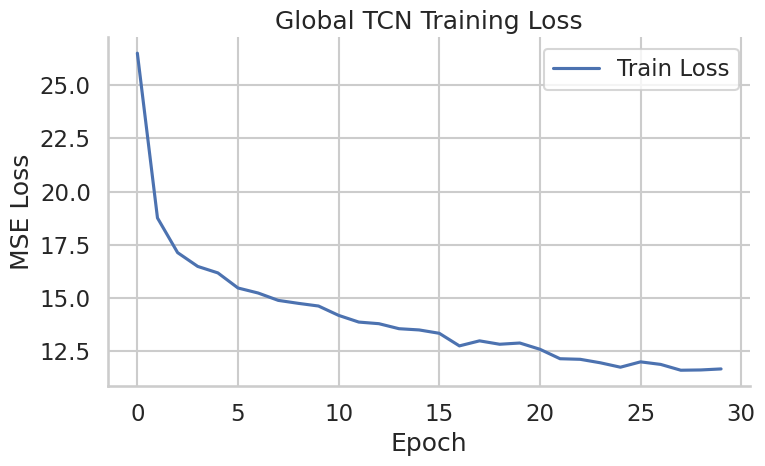

In [ ]:
# ============================================================
# CELL: Plot TCN Training History
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(tcn_history.history["loss"], label="Train Loss")
# Conditionally plot validation loss if it exists
if "val_loss" in tcn_history.history:
    plt.plot(tcn_history.history["val_loss"], label="Validation Loss")
plt.title(f"Global TCN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

## **25. STL for Selected Household**

In [ ]:
# ============================================================
# CELL: STL for Selected Household
# ============================================================

def run_stl_for_household(df_home, test_start, val_start, period=7):
    df_home = df_home.sort_values("date").copy()

    baseline_df = df_home[df_home["date"] < test_start].copy()
    test_df = df_home[df_home["date"] >= test_start].copy()

    if len(baseline_df) < 90 or len(test_df) == 0:
        return None, None, None

    expected_vals = []
    residuals = []

    for i in range(len(df_home)):
        current_date = df_home.iloc[i]["date"]

        if current_date < test_start:
            expected_vals.append(np.nan)
            residuals.append(np.nan)
            continue

        past_df = df_home.iloc[:i].copy()
        if len(past_df) < 60:
            expected_vals.append(np.nan)
            residuals.append(np.nan)
            continue

        stl_df = stl_baseline(past_df, period=period, min_days=60)
        if stl_df is None:
            expected_vals.append(np.nan)
            residuals.append(np.nan)
            continue

        expected_today = stl_df["expected_kWh"].iloc[-1]
        observed_today = df_home.iloc[i]["daily_kWh"]

        expected_vals.append(expected_today)
        residuals.append(observed_today - expected_today)

    df_home["expected_test"] = expected_vals
    df_home["residual_test"] = residuals

    baseline_residuals = df_home.loc[
        (df_home["date"] >= val_start) & (df_home["date"] < test_start),
        "residual_test"
    ].dropna().values

    home_test = df_home[df_home["date"] >= test_start].copy()
    r = home_test["residual_test"].fillna(0).values

    cusum_pos, cusum_neg, cusum_alert, k, h, mu0_c, sigma0_c = cusum_drift(
        r, baseline_residuals=baseline_residuals
    )

    ewma_vals, ewma_alert, ewma_upper, ewma_lower, mu0_e, sigma0_e = ewma_drift(
        r, baseline_residuals=baseline_residuals
    )

    home_test["cusum_pos"] = cusum_pos
    home_test["cusum_neg"] = cusum_neg
    home_test["cusum_alert"] = cusum_alert
    home_test["cusum_k"] = k
    home_test["cusum_h"] = h

    home_test["ewma"] = ewma_vals
    home_test["ewma_alert"] = ewma_alert
    home_test["ewma_upper"] = ewma_upper
    home_test["ewma_lower"] = ewma_lower

    summary = pd.DataFrame({
        "LCLid": [df_home["LCLid"].iloc[0]],
        "cusum_first_alert": [home_test.loc[home_test["cusum_alert"], "date"].min()],
        "cusum_num_alerts": [int(home_test["cusum_alert"].sum())],
        "cusum_max_drift": [float(np.max(np.abs(home_test["cusum_neg"]))) if len(home_test) else np.nan],
        "ewma_first_alert": [home_test.loc[home_test["ewma_alert"], "date"].min()],
        "ewma_num_alerts": [int(home_test["ewma_alert"].sum())],
        "ewma_max_drift": [float(np.max(np.abs(home_test["ewma"]))) if len(home_test) else np.nan]
    })

    return summary, home_test, baseline_residuals

## **26. Run STL on Selected Household**

In [ ]:
# ============================================================
# CELL: Run STL on Selected Household
# ============================================================

raw_one_house_stl = merged2_sel[merged2_sel["LCLid"] == SELECTED_HOUSE].copy().sort_values("date")
stl_summary_one, stl_test_one, stl_baseline_resid = run_stl_for_household(
    raw_one_house_stl,
    test_start=test_start,
    val_start=val_start,
    period=7
)

display(stl_summary_one)
stl_test_one.head()

,LCLid,cusum_first_alert,cusum_num_alerts,cusum_max_drift,ewma_first_alert,ewma_num_alerts,ewma_max_drift
0,MAC000006,NaT,0,0.000,NaT,0,1.006


,LCLid,date,daily_kWh,daily_kWh_log,temp_mean,temp_max,temp_min,carbon_intensity,expected_test,residual_test,cusum_pos,cusum_neg,cusum_alert,cusum_k,cusum_h,ewma,ewma_alert,ewma_upper,ewma_lower
2608,MAC000006,2013-12-31,3.307,1.460,8.000,11.400,5.100,408.188,4.313,-1.006,0.000,0.000,False,0.000,0.000,-1.006,False,NaN,NaN
2609,MAC000006,2014-01-01,3.637,1.534,8.500,11.100,5.600,396.000,3.354,0.283,0.000,0.000,False,0.000,0.000,-0.619,False,NaN,NaN
2610,MAC000006,2014-01-02,3.293,1.457,8.600,10.700,6.100,415.208,3.655,-0.362,0.000,0.000,False,0.000,0.000,-0.542,False,NaN,NaN
2611,MAC000006,2014-01-03,3.544,1.514,8.600,9.500,6.500,399.792,3.188,0.356,0.000,0.000,False,0.000,0.000,-0.273,False,NaN,NaN
2612,MAC000006,2014-01-04,3.438,1.490,7.400,12.500,5.300,440.500,3.399,0.039,0.000,0.000,False,0.000,0.000,-0.179,False,NaN,NaN


## **27. Early Detection for STL CUSUM and EWMA**

In [ ]:
# ============================================================
# CELL: Early Detection Evaluation for STL Alerts
# ============================================================

early_cusum = evaluate_early_detection(
    stl_test_one,
    alert_col="cusum_alert",
    residual_col="residual_test",
    baseline_residuals=stl_baseline_resid,
    consecutive_days=3,
    event_quantile=0.95
)

early_ewma = evaluate_early_detection(
    stl_test_one,
    alert_col="ewma_alert",
    residual_col="residual_test",
    baseline_residuals=stl_baseline_resid,
    consecutive_days=3,
    event_quantile=0.95
)

print("CUSUM early detection:", early_cusum)
print("EWMA early detection:", early_ewma)

CUSUM early detection: {'event_date': NaT, 'first_alert': NaT, 'lead_time_days': nan, 'false_alarm_rate': np.float64(0.0), 'stability_score': 0.0, 'event_threshold': np.float64(0.8468721699823395)}
EWMA early detection: {'event_date': NaT, 'first_alert': NaT, 'lead_time_days': nan, 'false_alarm_rate': np.float64(0.0), 'stability_score': 0.0, 'event_threshold': np.float64(0.8468721699823395)}


## **28. Add Drift Alerts for XGBoost and TCN**

In [ ]:
# ============================================================
# CELL: Drift Alerts on Forecast Errors (XGBoost and TCN)
# ============================================================

# XGBoost baseline residuals from validation
val_pred_xgb = best_xgb.predict(X_val)
baseline_resid_xgb = y_val.values - val_pred_xgb

xgb_errors_one = xgb_pred_df_one["error"].values
xgb_cusum_pos, xgb_cusum_neg, xgb_alerts, xgb_k, xgb_h, _, _ = cusum_drift(
    xgb_errors_one, baseline_residuals=baseline_resid_xgb
)

xgb_pred_df_one["xgb_cusum_pos"] = xgb_cusum_pos
xgb_pred_df_one["xgb_cusum_neg"] = xgb_cusum_neg
xgb_pred_df_one["xgb_alert"] = xgb_alerts

# TCN baseline residuals from validation
if X_val_tcn.shape[0] > 0:
    val_pred_tcn = tcn_model.predict(X_val_tcn, verbose=0).flatten()
    baseline_resid_tcn = y_val_tcn - val_pred_tcn
else:
    print("Skipping TCN validation prediction as X_val_tcn is empty. Using empty array for baseline residuals.")
    val_pred_tcn = np.array([]) # Ensure it's an empty numpy array
    baseline_resid_tcn = np.array([]) # Ensure it's an empty numpy array

tcn_errors_one = tcn_pred_df_one["error"].values
tcn_cusum_pos, tcn_cusum_neg, tcn_alerts, tcn_k, tcn_h, _, _ = cusum_drift(
    tcn_errors_one, baseline_residuals=baseline_resid_tcn
)

tcn_pred_df_one["tcn_cusum_pos"] = tcn_cusum_pos
tcn_pred_df_one["tcn_cusum_neg"] = tcn_cusum_neg
tcn_pred_df_one["tcn_alert"] = tcn_alerts

Skipping TCN validation prediction as X_val_tcn is empty. Using empty array for baseline residuals.


## **29. Summary Table for Selected Household**

In [ ]:
# ============================================================
# CELL: Selected Household Summary Table
# ============================================================

house_summary = pd.DataFrame({
    "LCLid": [SELECTED_HOUSE],

    "tcn_mae": [tcn_metrics_one["mae"]],
    "tcn_rmse": [tcn_metrics_one["rmse"]],
    "tcn_mape": [tcn_metrics_one["mape"]],
    "tcn_smape": [tcn_metrics_one["smape"]],
    "tcn_r2": [tcn_metrics_one["r2"]],
    "tcn_first_alert": [tcn_pred_df_one.loc[tcn_pred_df_one["tcn_alert"], "date"].min()],
    "tcn_num_alerts": [int(tcn_pred_df_one["tcn_alert"].sum())],
    "tcn_max_drift": [float(np.max(tcn_pred_df_one["tcn_cusum_pos"])) if len(tcn_pred_df_one) else np.nan],

    "xgb_mae": [xgb_metrics_one["mae"]],
    "xgb_rmse": [xgb_metrics_one["rmse"]],
    "xgb_mape": [xgb_metrics_one["mape"]],
    "xgb_smape": [xgb_metrics_one["smape"]],
    "xgb_r2": [xgb_metrics_one["r2"]],
    "xgb_first_alert": [xgb_pred_df_one.loc[xgb_pred_df_one["xgb_alert"], "date"].min()],
    "xgb_num_alerts": [int(xgb_pred_df_one["xgb_alert"].sum())],
    "xgb_max_drift": [float(np.max(xgb_pred_df_one["xgb_cusum_pos"])) if len(xgb_pred_df_one) else np.nan],

    "cusum_first_alert": [stl_summary_one["cusum_first_alert"].iloc[0] if stl_summary_one is not None else pd.NaT],
    "cusum_num_alerts": [stl_summary_one["cusum_num_alerts"].iloc[0] if stl_summary_one is not None else np.nan],
    "cusum_max_drift": [stl_summary_one["cusum_max_drift"].iloc[0] if stl_summary_one is not None else np.nan],

    "ewma_first_alert": [stl_summary_one["ewma_first_alert"].iloc[0] if stl_summary_one is not None else pd.NaT],
    "ewma_num_alerts": [stl_summary_one["ewma_num_alerts"].iloc[0] if stl_summary_one is not None else np.nan],
    "ewma_max_drift": [stl_summary_one["ewma_max_drift"].iloc[0] if stl_summary_one is not None else np.nan],

    "cusum_event_date": [early_cusum["event_date"]],
    "cusum_first_alert_eval": [early_cusum["first_alert"]],
    "cusum_lead_time_days": [early_cusum["lead_time_days"]],
    "cusum_false_alarm_rate": [early_cusum["false_alarm_rate"]],

    "ewma_event_date": [early_ewma["event_date"]],
    "ewma_first_alert_eval": [early_ewma["first_alert"]],
    "ewma_lead_time_days": [early_ewma["lead_time_days"]],
    "ewma_false_alarm_rate": [early_ewma["false_alarm_rate"]],
})

display(house_summary)

,LCLid,tcn_mae,tcn_rmse,tcn_mape,tcn_smape,tcn_r2,tcn_first_alert,tcn_num_alerts,tcn_max_drift,xgb_mae,xgb_rmse,xgb_mape,xgb_smape,xgb_r2,xgb_first_alert,xgb_num_alerts,xgb_max_drift,cusum_first_alert,cusum_num_alerts,cusum_max_drift,ewma_first_alert,ewma_num_alerts,ewma_max_drift,cusum_event_date,cusum_first_alert_eval,cusum_lead_time_days,cusum_false_alarm_rate,ewma_event_date,ewma_first_alert_eval,ewma_lead_time_days,ewma_false_alarm_rate
0,MAC000006,0.963,1.122,141.450,27.571,-3.356,NaT,0,0.000,0.348,0.550,97.569,12.089,-0.046,NaT,0,0.000,NaT,0,0.000,NaT,0,1.006,NaT,NaT,NaN,0.000,NaT,NaT,NaN,0.000


## **30. Forecast Plot for Selected Household**

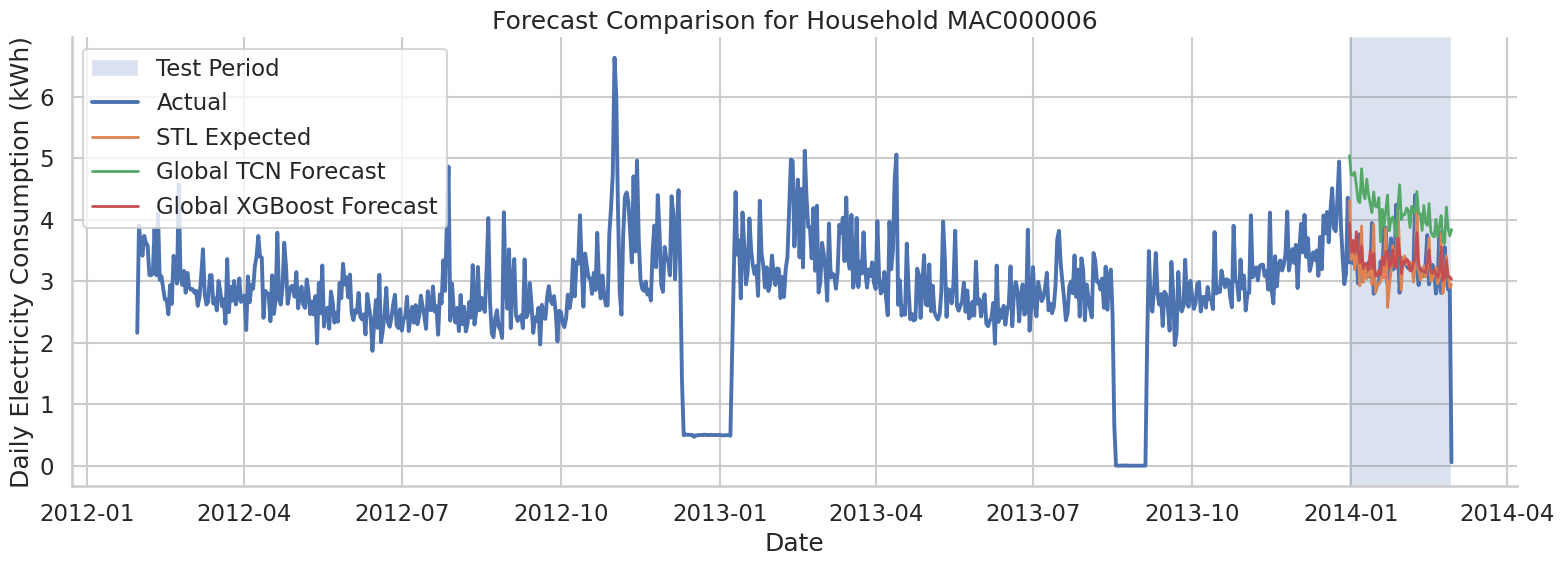

In [ ]:
# ============================================================
# CELL: Forecast Comparison Plot
# ============================================================

plt.figure(figsize=(16, 6))
plt.axvspan(test_start, raw_one_house["date"].max(), alpha=0.2, label="Test Period")

plt.plot(raw_one_house["date"], raw_one_house["daily_kWh"], label="Actual", linewidth=2.8)

if stl_test_one is not None and "expected_test" in stl_test_one.columns:
    plt.plot(stl_test_one["date"], stl_test_one["expected_test"], label="STL Expected", linewidth=2)

plt.plot(tcn_pred_df_one["date"], tcn_pred_df_one["predicted"], label="Global TCN Forecast", linewidth=2)
plt.plot(xgb_pred_df_one["date"], xgb_pred_df_one["predicted"], label="Global XGBoost Forecast", linewidth=2)

plt.title(f"Forecast Comparison for Household {SELECTED_HOUSE}")
plt.xlabel("Date")
plt.ylabel("Daily Electricity Consumption (kWh)")
plt.legend()
plt.tight_layout()
plt.show()

## **31. Drift Plot for STL**

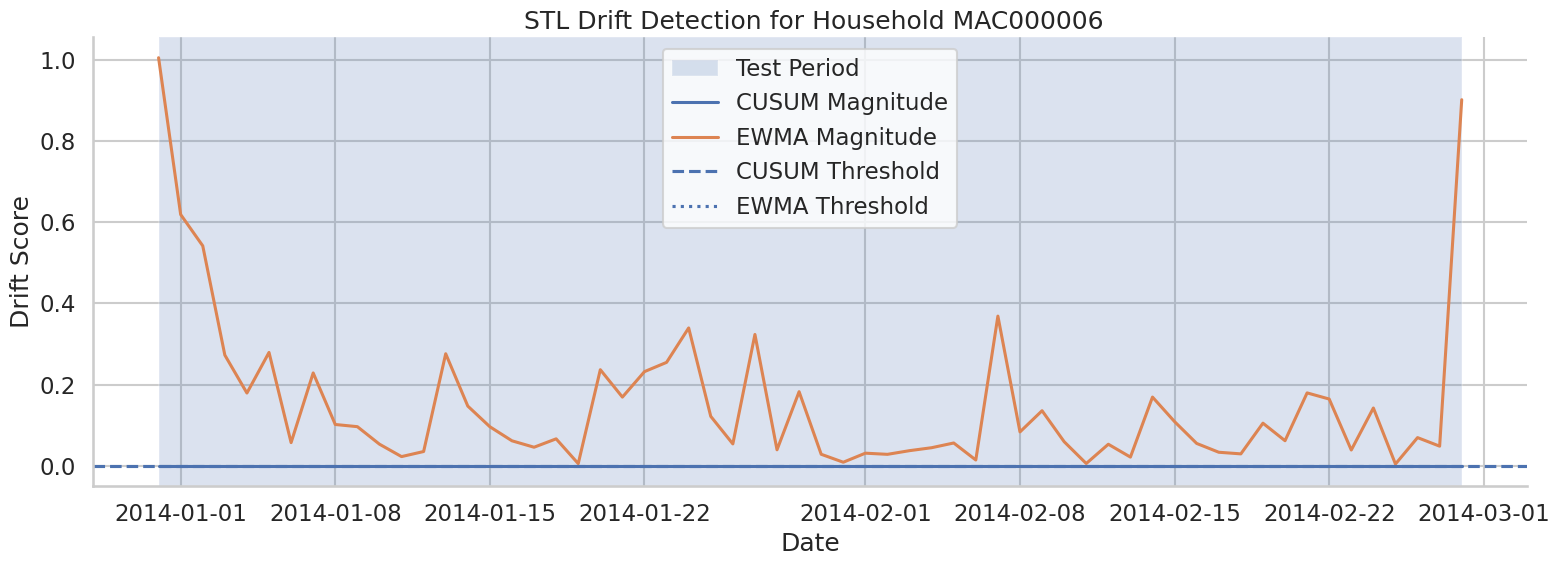

In [ ]:

if stl_test_one is not None:
    plt.figure(figsize=(16, 6))
    plt.axvspan(test_start, stl_test_one["date"].max(), alpha=0.2, label="Test Period")

    plt.plot(stl_test_one["date"], np.abs(stl_test_one["cusum_neg"]), label="CUSUM Magnitude", linewidth=2.2)
    plt.plot(stl_test_one["date"], np.abs(stl_test_one["ewma"]), label="EWMA Magnitude", linewidth=2.2)

    if "cusum_h" in stl_test_one.columns:
        plt.axhline(stl_test_one["cusum_h"].iloc[0], linestyle="--", label="CUSUM Threshold")

    if "ewma_upper" in stl_test_one.columns:
        plt.axhline(abs(stl_test_one["ewma_upper"].iloc[0]), linestyle=":", label="EWMA Threshold")

    alert_dates = stl_test_one.loc[stl_test_one["cusum_alert"] == True, "date"]
    for i, d in enumerate(alert_dates):
        plt.axvline(d, color="red", linestyle="--", alpha=0.3, label="CUSUM Alert" if i == 0 else "")

    plt.title(f" STL Drift Detection for Household {SELECTED_HOUSE}")
    plt.xlabel("Date")
    plt.ylabel("Drift Score")
    plt.legend()
    plt.tight_layout()
    plt.show()

## **32. Error Drift Plot for TCN and XGBoost**

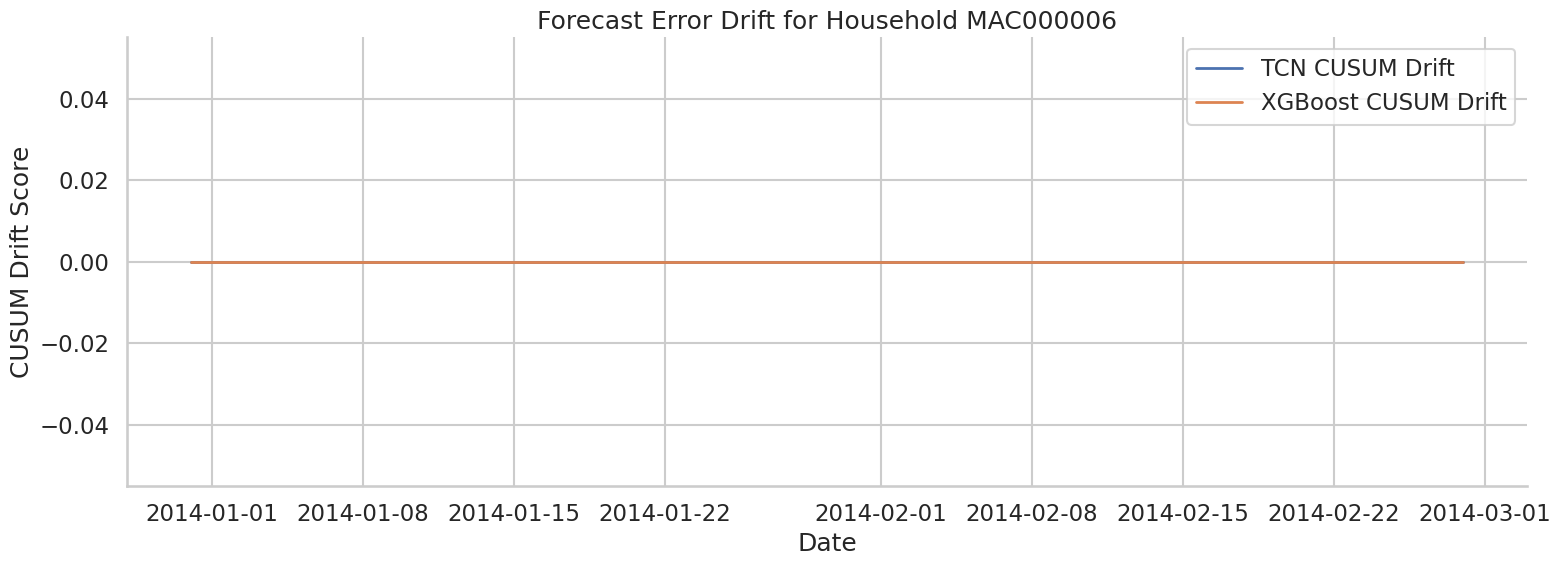

In [ ]:
# ============================================================
# CELL: Forecast Error Drift Plot
# ============================================================

plt.figure(figsize=(16, 6))
plt.plot(tcn_pred_df_one["date"], np.abs(tcn_pred_df_one["tcn_cusum_pos"]), label="TCN CUSUM Drift", linewidth=2)
plt.plot(xgb_pred_df_one["date"], np.abs(xgb_pred_df_one["xgb_cusum_pos"]), label="XGBoost CUSUM Drift", linewidth=2)

plt.title(f"Forecast Error Drift for Household {SELECTED_HOUSE}")
plt.xlabel("Date")
plt.ylabel("CUSUM Drift Score")
plt.legend()
plt.tight_layout()
plt.show()

## **33. SHAP for Global XGBoost on Selected Household**

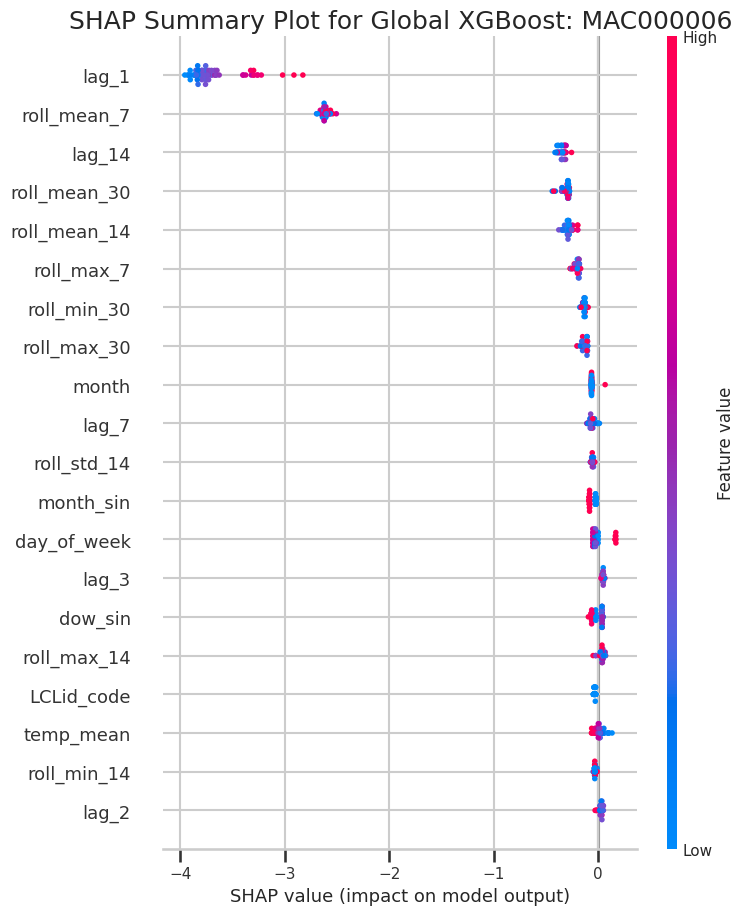

In [ ]:
# ============================================================
# CELL: SHAP for Global XGBoost
# ============================================================

X_test_xgb_shap = test_one_house_xgb[feature_cols].copy()

explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test_xgb_shap)

shap.summary_plot(shap_values, X_test_xgb_shap, show=False)
plt.title(f"SHAP Summary Plot for Global XGBoost: {SELECTED_HOUSE}")
plt.tight_layout()
plt.show()

## **34. Export Output Files**

In [ ]:
# ============================================================
# CELL: Export Outputs
# ============================================================

os.makedirs("outputs", exist_ok=True)

house_summary.to_csv(f"outputs/{SELECTED_HOUSE}_summary.csv", index=False)
tcn_pred_df_one.to_csv(f"outputs/{SELECTED_HOUSE}_tcn_detail.csv", index=False)
xgb_pred_df_one.to_csv(f"outputs/{SELECTED_HOUSE}_xgb_detail.csv", index=False)

if stl_test_one is not None:
    stl_test_one.to_csv(f"outputs/{SELECTED_HOUSE}_stl_detail.csv", index=False)

print("Improved output files exported successfully.")

Improved output files exported successfully.


## **30. Explainable AI**

**30.1 SHAP for XGBoost**

In [ ]:
house_for_xai = SELECTED_HOUSE
xgb_model = xgb_models.get(house_for_xai, None)

df_home_xgb = df_model[df_model["LCLid"] == house_for_xai].copy()
feature_cols = [c for c in df_home_xgb.columns if c not in ["LCLid", "date", "daily_kWh", "daily_kWh_log"]]

xgb_test_df = df_home_xgb[df_home_xgb["date"] >= test_start].copy()
X_test_xgb = xgb_test_df[feature_cols]

if xgb_model is not None and len(X_test_xgb) > 0:
    explainer = shap.Explainer(xgb_model)
    shap_values = explainer(X_test_xgb)

    shap.summary_plot(shap_values, X_test_xgb, show=False)
    plt.title(f"SHAP Summary Plot for XGBoost: {house_for_xai}")
    plt.tight_layout()
    plt.show()



**30.2 Permutation Importance for TCN**

In [ ]:
def tcn_permutation_importance_from_series(df_home, lookback=30, test_start=None, val_start=None, epochs=20):
    df_home = df_home.sort_values("date")[["date", "daily_kWh"]].dropna().copy()
    scaler = MinMaxScaler()
    df_home["scaled"] = scaler.fit_transform(df_home[["daily_kWh"]])

    X, y, dates = [], [], []
    series = df_home["scaled"].values
    date_vals = df_home["date"].values

    for i in range(lookback, len(series)):
        X.append(series[i-lookback:i])
        y.append(series[i])
        dates.append(date_vals[i])

    X = np.array(X)
    y = np.array(y)
    dates = pd.to_datetime(np.array(dates))

    train_mask = dates < val_start
    val_mask = (dates >= val_start) & (dates < test_start)
    test_mask = dates >= test_start

    X_train = X[train_mask][..., np.newaxis]
    y_train = y[train_mask]
    X_test = X[test_mask][..., np.newaxis]
    y_test = y[test_mask]

    if val_mask.sum() > 0:
        X_val = X[val_mask][..., np.newaxis]
        y_val = y[val_mask]
    else:
        return None, None

    model = Sequential([
        TCN(32, dropout_rate=0.1),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=16,
        verbose=0,
        callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
    )

    baseline_pred = model.predict(X_test, verbose=0).flatten()
    baseline_error = mean_absolute_error(y_test, baseline_pred)

    importances = []
    feature_names = ["energy_sequence"]

    for f in range(X_test.shape[2]):
        X_perm = X_test.copy()
        np.random.shuffle(X_perm[:, :, f])
        pred = model.predict(X_perm, verbose=0).flatten()
        error = mean_absolute_error(y_test, pred)
        importances.append(error - baseline_error)

    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    return imp_df, model

In [ ]:
perm_df, _ = tcn_permutation_importance_from_series(
merged2[merged2["LCLid"] == SELECTED_HOUSE].copy(),
    lookback=30,
    test_start=test_start,
    val_start=val_start,
    epochs=10
)

if perm_df is not None:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=perm_df, x="importance", y="feature")
    plt.title(f"TCN Permutation Importance: {best_house}")
    plt.xlabel("Increase in MAE")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

## **31. Carbon Impact Analysis**

### **31.1 Carbon Impact for STL Residuals**

In [ ]:
carbon_records = []

for hid, home_test in stl_details.items():
    temp = compute_excess_carbon(home_test, residual_col="residual_test")
    carbon_records.append({
        "LCLid": hid,
        "excess_energy_kwh": temp["positive_residual"].sum(),
        "excess_carbon_g": temp["excess_carbon_g"].sum()
    })

carbon_summary = pd.DataFrame(carbon_records).sort_values("excess_carbon_g", ascending=False)
carbon_summary.head(10)

### **31.2 Energy Drift vs Carbon Drift for Showcase Household**

In [ ]:
## **31. Carbon Impact Analysis**

NameError: name 'results' is not defined

## **32. Dashboard-Ready Export Files**

In [ ]:
os.makedirs("outputs", exist_ok=True)

comparison.to_csv("outputs/comparison_summary.csv", index=False)
early_eval.to_csv("outputs/early_detection_eval.csv", index=False)
carbon_summary.to_csv("outputs/carbon_summary.csv", index=False)

if results["stl_test"] is not None:
    results["stl_test"].to_csv(f"outputs/{SELECTED_HOUSE}_stl_detail.csv", index=False)

if results["tcn_pred_df"] is not None:
    results["tcn_pred_df"].to_csv(f"outputs/{SELECTED_HOUSE}_tcn_detail.csv", index=False)

if results["xgb_pred_df"] is not None:
    results["xgb_pred_df"].to_csv(f"outputs/{SELECTED_HOUSE}_xgb_detail.csv", index=False)

house_summary.to_csv(f"outputs/{SELECTED_HOUSE}_summary.csv", index=False)
print("Dashboard-ready files exported.")

## **33. Minimal Streamlit App Prototype**

In [ ]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(page_title="Energy Drift Dashboard", layout="wide")
st.title("Household Energy Drift Detection Dashboard")

comparison = pd.read_csv("outputs/comparison_summary.csv")
carbon_summary = pd.read_csv("outputs/carbon_summary.csv")

households = comparison["LCLid"].dropna().unique().tolist()
selected_house = st.selectbox("Select Household", households)

st.subheader("Comparison Summary")
st.dataframe(comparison[comparison["LCLid"] == selected_house])

st.subheader("Top Carbon Impact Households")
st.dataframe(carbon_summary.head(10))

try:
    stl_df = pd.read_csv(f"outputs/{selected_house}_stl_detail.csv")
    stl_df["date"] = pd.to_datetime(stl_df["date"])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(stl_df["date"], stl_df["daily_kWh"], label="Actual")
    if "expected_test" in stl_df.columns:
        ax.plot(stl_df["date"], stl_df["expected_test"], label="STL Expected")
    ax.legend()
    ax.set_title(f"Consumption for {selected_house}")
    st.pyplot(fig)
except:
    st.info("Detailed STL file not found for this household.")